In [9]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

In [2]:
x,y = make_regression(n_samples=100,
                      n_features=1,
                      n_informative=1,
                      n_targets=1,
                      noise=20,
                      random_state=13)

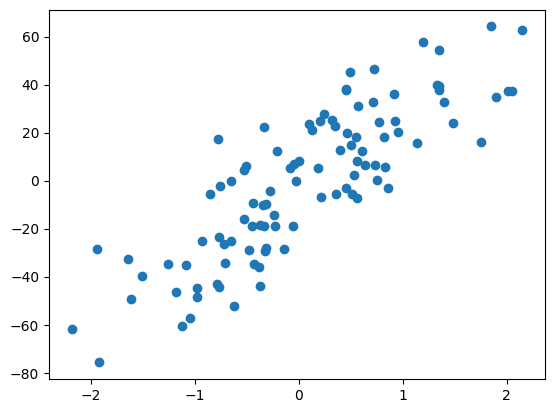

In [6]:
plt.scatter(x,y)
plt.show()

In [8]:
lr = LinearRegression()
lr.fit(x,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [10]:
rr = Ridge(alpha=10)
rr.fit(x,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235735


In [11]:
rr1 = Ridge(alpha=100)
rr1.fit(x,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


In [15]:
rr2 = Ridge(alpha=1000)
rr2.fit(x,y)
print(rr2.coef_)
print(rr2.intercept_)

[2.22362237]
-0.7992543425229544


In [16]:
rr3 = Ridge(alpha=10000)
rr3.fit(x,y)
print(rr3.coef_)
print(rr3.intercept_)

[0.23959256]
-0.6833723373459936


In [18]:
rr4 = Ridge(alpha=100000)
rr4.fit(x,y)
print(rr4.coef_)
print(rr4.intercept_)

[0.02414636]
-0.6707886867998882


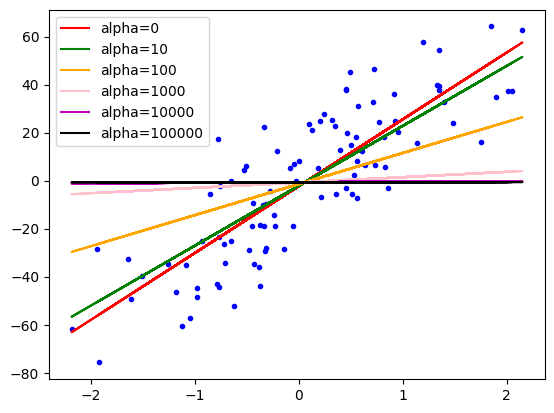

In [20]:
plt.plot(x,y,'b.')
plt.plot(x,lr.predict(x),color='red',label='alpha=0')
plt.plot(x,rr.predict(x),color='green',label='alpha=10')
plt.plot(x,rr1.predict(x),color='orange',label='alpha=100')
plt.plot(x,rr2.predict(x),color='pink',label='alpha=1000')
plt.plot(x,rr3.predict(x),color='m',label='alpha=10000')
plt.plot(x,rr4.predict(x),color='black',label='alpha=100000')
plt.legend()
plt.show()

## Using OLS

In [26]:
class MeraRidge:

    def __init__(self,alpha=0.1):
        self.alpha= alpha
        self.m = None
        self.b = None

    def fit(self,x_train,y_train):

        num = 0
        den = 0

        for i in range(x_train.shape[0]):
            num = num + (y_train[i]-y_train.mean())*(x_train[i]-x_train.mean())
            den = den + (x_train[i]-x_train.mean())**2

        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m)*(x_train.mean())
        print(self.m,self.b)

    def predict(self,x_test):
        return (self.m)*x_test + (self.b) + (self.alpha)*((self.m)**2)

In [27]:
reg = MeraRidge(alpha=10)

In [28]:
reg.fit(x,y)

[24.9546267] [-2.126913]
